In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Veriyi yüklüyoruz
df = pd.read_csv('Customer Data.csv')

# İlk birkaç satıra göz atalım
print(df.head())

  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000       

In [3]:
# Müşteri ID sütununu analiz dışı bırakıyoruz
X = df.drop('CUST_ID', axis=1)

# Eksik (Missing) değerleri sütunların medyan değerleriyle dolduruyoruz
X = X.fillna(X.median())

# Verileri standartlaştırıyoruz (Scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

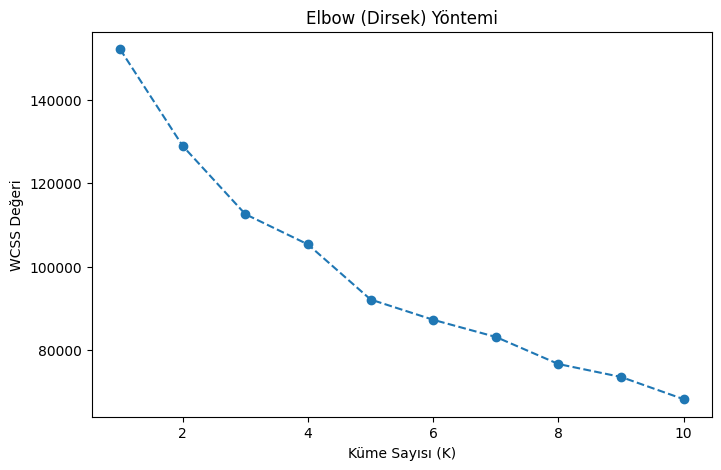

In [4]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Dirsek (Elbow) Grafiğinin Çizilmesi
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow (Dirsek) Yöntemi')
plt.xlabel('Küme Sayısı (K)')
plt.ylabel('WCSS Değeri')
plt.show()

In [5]:
# Optimal küme sayısını 4 kabul ederek modeli oluşturuyoruz
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Bulunan küme sonuçlarını orijinal veri setimize yeni bir sütun olarak ekliyoruz
df['Cluster'] = cluster_labels

# Hangi kümede kaç müşteri var kontrol edelim
print(df['Cluster'].value_counts())

Cluster
3    3368
2    3118
1    1487
0     977
Name: count, dtype: int64


             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
0        5010.394668           0.966663   716.017789        450.235875   
1         108.430006           0.412096   350.247868        190.521089   
2        1253.817942           0.974758  2182.022178       1241.768493   
3        1495.324927           0.966467   283.482824        210.004454   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                    265.885977   5065.974690             0.327150   
1                    160.197189    299.482324             0.320591   
2                    940.517248    234.564524             0.928413   
3                     73.794186    782.285268             0.207097   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                                      

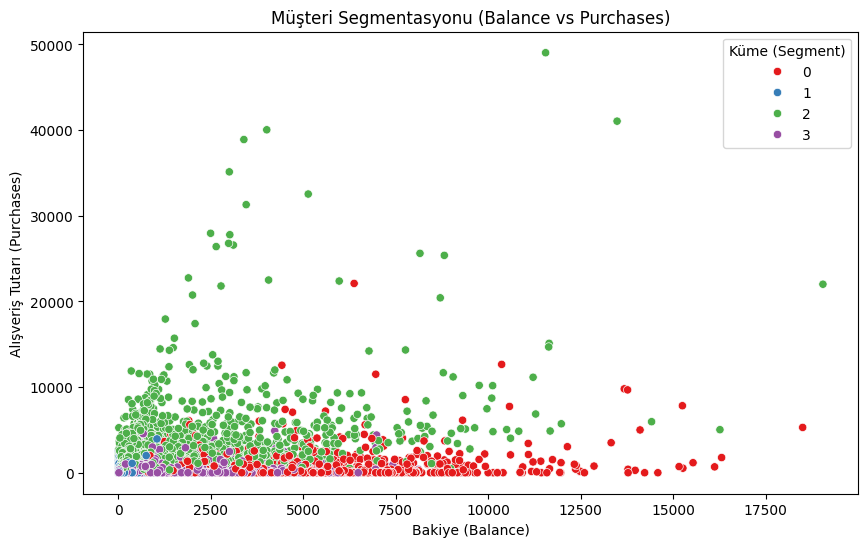

In [6]:
# Kümelerin sütun bazında ortalama değerleri
cluster_analysis = df.drop('CUST_ID', axis=1).groupby('Cluster').mean()
print(cluster_analysis)

# Örnek Görselleştirme: Bakiye (BALANCE) ve Alışveriş Tutarı (PURCHASES) dağılımı
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='BALANCE', y='PURCHASES', hue='Cluster', palette='Set1')
plt.title('Müşteri Segmentasyonu (Balance vs Purchases)')
plt.xlabel('Bakiye (Balance)')
plt.ylabel('Alışveriş Tutarı (Purchases)')
plt.legend(title='Küme (Segment)')
plt.show()